In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
skin_props = pd.read_csv("../data/spectral_skin_props.csv", header=None)
spectral_reflectance = pd.read_csv("../data/spectral_reflectance_diffuse_smoothed.csv")

In [12]:
skin_props.head()

,0,1,2,3,4,5
0,0.101948,0.571833,0.137171,0.919402,0.771286,1.0
1,0.621212,0.309605,0.516795,0.908268,0.861961,1.0
2,0.240661,0.470882,0.375613,0.918288,0.422154,1.0
3,0.506206,0.539464,0.276220,0.937283,0.529060,1.0
4,0.439793,0.656163,0.141996,0.965000,0.344602,1.0


In [13]:
skin_props.shape

(1282, 6)

In [14]:
# calculate the mean, min, and max for each column in skin_props
skin_props_mean = skin_props.mean()
skin_props_min = skin_props.min()
skin_props_max = skin_props.max()
skin_props_stats = pd.DataFrame({
    "mean": skin_props_mean,
    "min": skin_props_min,
    "max": skin_props_max
}) 
skin_props_stats

,mean,min,max
0,0.416611,0.100750,0.736788
1,0.426902,0.178328,0.668681
2,0.380274,0.059140,0.705192
3,0.939909,0.900138,0.979989
4,0.489933,0.100469,0.899948
5,1.000000,1.000000,1.000000


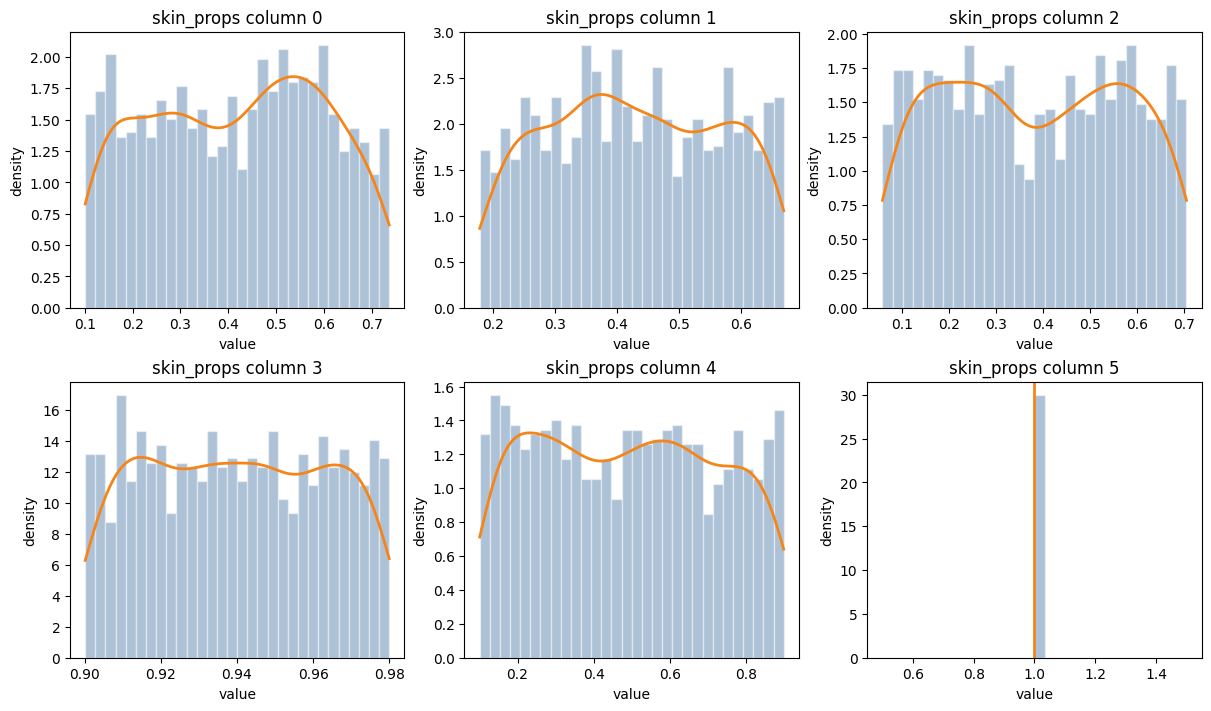

In [17]:
n_cols = 3
n_rows = int(np.ceil(skin_props.shape[1] / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), constrained_layout=True)
axes = np.ravel(axes)

for ax, column in zip(axes, skin_props.columns):
    values = skin_props[column].dropna().to_numpy()
    ax.hist(values, bins=30, density=True, alpha=0.45, color="#4C78A8", edgecolor="white")

    if values.size > 1 and np.std(values) > 0:
        grid = np.linspace(values.min(), values.max(), 300)
        bandwidth = 1.06 * np.std(values, ddof=1) * values.size ** (-1 / 5)
        density = np.exp(-0.5 * ((grid[:, None] - values[None, :]) / bandwidth) ** 2).sum(axis=1)
        density /= values.size * bandwidth * np.sqrt(2 * np.pi)
        ax.plot(grid, density, color="#F58518", linewidth=2)
    else:
        ax.axvline(values[0], color="#F58518", linewidth=2)

    ax.set_title(f"skin_props column {column}")
    ax.set_xlabel("value")
    ax.set_ylabel("density")

for ax in axes[skin_props.shape[1]:]:
    ax.set_visible(False)

plt.show()

In [19]:
import pandas as pd

SKIN_PROPS = [
    "Melanin",
    "Hemoglobin",
    "Thickness",
    "Blood oxygenation",
    "Melanin type ratio",
    "Occlusion",
]

# Regular range, excluding localized effects such as rashes or spots.
REGULAR_SKIN_MIN_VALUES = [0.005, 0.001, 0.005, 0.6, 0.72, 1.0]
REGULAR_SKIN_MAX_VALUES = [0.40, 0.0225, 0.025, 0.8, 0.76, 1.0]

# Plausible range.
SKIN_MIN_VALUES = [0.001, 0.001, 0.001, 0.001, 0.001, 1.0]
SKIN_MAX_VALUES = [0.45, 0.25, 0.035, 1.0, 1.0, 1.0]

# Full parameter range.
MIN_PROP_VALUES = [0.001, 0.001, 0.001, 0.001, 0.001, 1.0]
MAX_PROP_VALUES = [1.0, 1.0, 0.035, 1.0, 1.0, 1.0]

parameter_ranges = pd.DataFrame(
    {
        "Parameter": SKIN_PROPS,
        "Regular minimum": REGULAR_SKIN_MIN_VALUES,
        "Regular maximum": REGULAR_SKIN_MAX_VALUES,
        "Plausible minimum": SKIN_MIN_VALUES,
        "Plausible maximum": SKIN_MAX_VALUES,
        "Full minimum": MIN_PROP_VALUES,
        "Full maximum": MAX_PROP_VALUES,
    }
)

parameter_ranges

,Parameter,Regular minimum,Regular maximum,Plausible minimum,Plausible maximum,Full minimum,Full maximum
0,Melanin,0.005,0.4000,0.001,0.450,0.001,1.000
1,Hemoglobin,0.001,0.0225,0.001,0.250,0.001,1.000
2,Thickness,0.005,0.0250,0.001,0.035,0.001,0.035
3,Blood oxygenation,0.600,0.8000,0.001,1.000,0.001,1.000
4,Melanin type ratio,0.720,0.7600,0.001,1.000,0.001,1.000
5,Occlusion,1.000,1.0000,1.000,1.000,1.000,1.000


In [24]:
n = 3000
rng = np.random.default_rng(42)

full_min = np.array(MIN_PROP_VALUES)
full_max = np.array(MAX_PROP_VALUES)

full_spectral_skin_props = pd.DataFrame(
    rng.uniform(full_min, full_max, size=(n, len(SKIN_PROPS))),
    columns=SKIN_PROPS,
)

full_spectral_skin_props.to_csv("../data/full_spectral_skin_props.csv", index=False, header=False)

full_spectral_skin_props.head()

,Melanin,Hemoglobin,Thickness,Blood oxygenation,Melanin type ratio,Occlusion
0,0.774182,0.439440,0.030192,0.697671,0.095083,1.0
1,0.761379,0.786278,0.005356,0.450936,0.371427,1.0
2,0.644221,0.822939,0.016076,0.228011,0.555030,1.0
3,0.827804,0.632033,0.026775,0.355171,0.970727,1.0
4,0.778605,0.195444,0.016869,0.044760,0.155135,1.0


In [25]:
n = 3000
rng = np.random.default_rng(42)

plausible_min = np.array(SKIN_MIN_VALUES)
plausible_max = np.array(SKIN_MAX_VALUES)

plausible_spectral_skin_props = pd.DataFrame(
    rng.uniform(plausible_min, plausible_max, size=(n, len(SKIN_PROPS))),
    columns=SKIN_PROPS,
)

plausible_spectral_skin_props.to_csv("../data/plausible_spectral_skin_props.csv", index=False, header=False)

plausible_spectral_skin_props.head()

,Melanin,Hemoglobin,Thickness,Blood oxygenation,Melanin type ratio,Occlusion
0,0.348506,0.110281,0.030192,0.697671,0.095083,1.0
1,0.342752,0.196730,0.005356,0.450936,0.371427,1.0
2,0.290095,0.205868,0.016076,0.228011,0.555030,1.0
3,0.372606,0.158284,0.026775,0.355171,0.970727,1.0
4,0.350494,0.049465,0.016869,0.044760,0.155135,1.0


In [26]:
n = 3000
rng = np.random.default_rng(42)

regular_min = np.array(REGULAR_SKIN_MIN_VALUES)
regular_max = np.array(REGULAR_SKIN_MAX_VALUES)

regular_spectral_skin_props = pd.DataFrame(
    rng.uniform(regular_min, regular_max, size=(n, len(SKIN_PROPS))),
    columns=SKIN_PROPS,
)

regular_spectral_skin_props.to_csv("../data/regular_spectral_skin_props.csv", index=False, header=False)

regular_spectral_skin_props.head()

,Melanin,Hemoglobin,Thickness,Blood oxygenation,Melanin type ratio,Occlusion
0,0.310713,0.010436,0.022172,0.739474,0.723767,1.0
1,0.305650,0.017900,0.007562,0.690077,0.734832,1.0
2,0.259327,0.018689,0.013868,0.645448,0.742183,1.0
3,0.331914,0.014581,0.020162,0.670905,0.758828,1.0
4,0.312461,0.005185,0.014334,0.608761,0.726172,1.0
